# 01 · Data audit — PhysioNet 2019 sepsis data

**Goal of this notebook:** understand the data *before* any modelling decision is made.
What is in it, what is missing, what is wrong, and how the two hospitals differ.

Nothing here changes the data. Every issue found becomes a numbered **decision for Step 2**
at the end, so each later choice can be traced back to evidence.

**The hospital B rule.** Hospital B is the locked external test set (see `PROJECT_PLAN.md`).
This notebook describes B's *inputs* only — its sepsis labels are never loaded
(`src/data.py` drops them before returning, so this cannot happen by accident).

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import data, viz
viz.apply()
pd.set_option("display.max_columns", 50, "display.width", 160)

A = data.load_a()
B = data.load_b_inputs()
print(f"Hospital A: {len(A):,} patient-hours, {A.patient_id.nunique():,} patients")
print(f"Hospital B: {len(B):,} patient-hours, {B.patient_id.nunique():,} patients  (label column present: {'SepsisLabel' in B})")

Hospital A: 790,215 patient-hours, 20,336 patients
Hospital B: 761,995 patient-hours, 20,000 patients  (label column present: False)


## 1 · Size and structure

One row per patient per ICU hour. Each patient's rows are contiguous hours.

In [2]:
def stay_summary(df):
    L = df.groupby("patient_id").size()
    return pd.Series({"patients": len(L), "patient-hours": L.sum(), "median stay (h)": L.median(),
                      "IQR (h)": f"{L.quantile(.25):.0f}–{L.quantile(.75):.0f}",
                      "shortest (h)": L.min(), "longest (h)": L.max()})
pd.DataFrame({"A": stay_summary(A), "B": stay_summary(B)})

,A,B
patients,20336,20000
patient-hours,790215,761995
median stay (h),39.0,38.0
IQR (h),25–47,23–47
shortest (h),8,8
longest (h),336,336


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


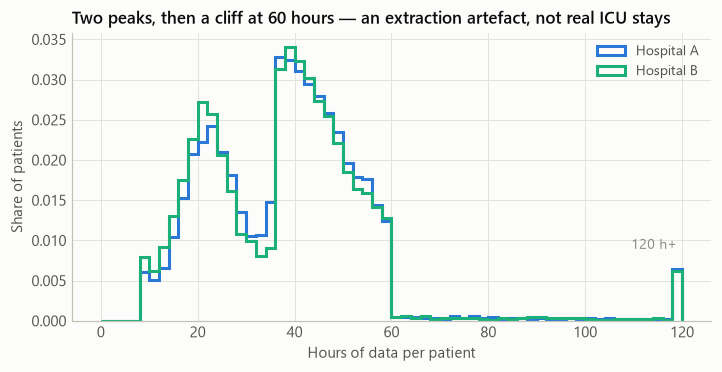

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
bins = np.arange(0, 121, 2)
for h, df in [("A", A), ("B", B)]:
    L = df.groupby("patient_id").size().clip(upper=120)
    ax.hist(L, bins=bins, histtype="step", lw=2, color=viz.COLORS[h], density=True, label=f"Hospital {h}")
ax.set(title="Two peaks, then a cliff at 60 hours — an extraction artefact, not real ICU stays",
       xlabel="Hours of data per patient", ylabel="Share of patients")
ax.text(119, ax.get_ylim()[1] * 0.25, "120 h+", color=viz.MUTED, ha="right", fontsize=9)
ax.legend(loc="upper right")
viz.save(fig, "01_stay_length")

The two hospitals look almost identical, and the shape is not what real ICU stays look like:
**two peaks (around 20 and 40 hours), then a cliff at 60 hours** with almost no records
between 60 and 120 hours, and a small group running longer. That is a trace of how the
challenge organisers cut records out of longer stays. Two consequences: record length is not
length of stay, and it should never be read as a clinical variable.

### Records don't always start at ICU hour 1
`ICULOS` is hours since ICU admission. If records began at admission it would start at 1.

In [4]:
start = A.groupby("patient_id").ICULOS.min()
print(f"Record starts at ICULOS 1: {(start==1).mean():.1%} of patients  |  later: {(start>1).mean():.1%}")
print(f"Contiguous (no gaps in ICULOS): {(A.groupby('patient_id').ICULOS.agg(lambda s: s.max()-s.min()+1==len(s))).mean():.1%}")
start.clip(upper=10).value_counts().sort_index().rename(index={10: "10+"}).to_frame("patients")

Record starts at ICULOS 1: 63.1% of patients  |  later: 36.9%


Contiguous (no gaps in ICULOS): 100.0%


,patients
ICULOS,
1,12839
2,3388
3,1678
4,1003
5,576
6,369
7,208
8,109
9,60


About a third of patients' records begin a few hours into their ICU stay. So **the row
number is not the same as time since ICU admission** — any "time in ICU" feature must use
`ICULOS`, not the row index.

## 2 · Sepsis in hospital A

`SepsisLabel` switches to 1 six hours *before* clinical onset and stays on.

In [5]:
pt = A.groupby("patient_id").agg(septic=("SepsisLabel", "max"), hours=("hour", "size"))
first = A[A.SepsisLabel == 1].groupby("patient_id").agg(first_hour=("hour", "min"), first_iculos=("ICULOS", "min"))
mono = A[A.patient_id.isin(first.index)].groupby("patient_id").SepsisLabel.apply(lambda s: s.is_monotonic_increasing)
after = pt.loc[first.index, "hours"] - 1 - first.first_hour

tiles = pd.Series({
    "patients who develop sepsis": f"{int(pt.septic.sum()):,} of {len(pt):,}  ({pt.septic.mean():.1%})",
    "patient-hours labelled 1": f"{A.SepsisLabel.mean():.2%}",
    "label never switches back off": f"{mono.mean():.0%} of septic patients",
    "label already on in the first row": f"{int((first.first_hour == 0).sum()):,} patients",
    "label on within the first 6 rows": f"{int((first.first_hour < 6).sum()):,} patients",
    "rows kept after the label switches on": f"median {after.median():.0f}, max {after.max():.0f}",
})
tiles.to_frame("hospital A")

,hospital A
patients who develop sepsis,"1,790 of 20,336 (8.8%)"
patient-hours labelled 1,2.17%
label never switches back off,100% of septic patients
label already on in the first row,203 patients
label on within the first 6 rows,406 patients
rows kept after the label switches on,"median 9, max 9"


,count,mean,std,min,10%,25%,50%,75%,90%,max
onset hour,1790.0,57.0,57.8,7.0,8.0,14.0,35.5,79.0,139.2,337.0


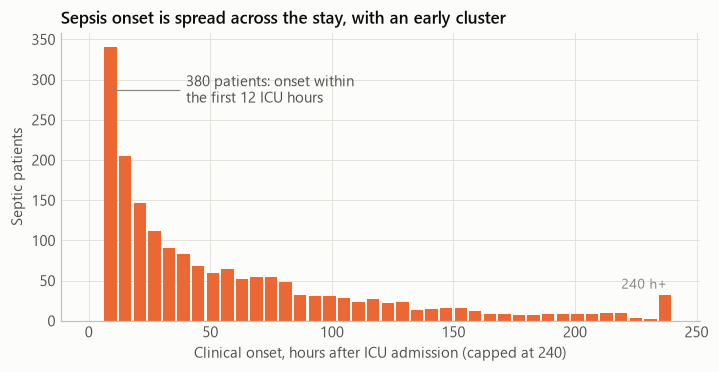

In [6]:
onset = (first.first_iculos + 6)   # clinical onset hour = first labelled ICU hour + 6
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.hist(onset.clip(upper=240), bins=np.arange(0, 245, 6), color=viz.COLORS["sepsis"], rwidth=0.85)
ax.text(238, 40, "240 h+", color=viz.MUTED, ha="right", fontsize=9)
ax.set(title="Sepsis onset is spread across the stay, with an early cluster",
       xlabel="Clinical onset, hours after ICU admission (capped at 240)", ylabel="Septic patients")
early = int((onset <= 12).sum())
ax.annotate(f"{early} patients: onset within\nthe first 12 ICU hours", xy=(9, ax.get_ylim()[1]*0.8),
            xytext=(40, ax.get_ylim()[1]*0.8), color=viz.INK_2, va="center",
            arrowprops=dict(arrowstyle="-", color=viz.MUTED, lw=0.8))
viz.save(fig, "01_onset_time")
onset.describe(percentiles=[.1, .25, .5, .75, .9]).round(1).to_frame("onset hour").T

Three things here shape the modelling design:

1. **Sepsis is rare per hour.** About 9% of patients, but only ~2% of patient-hours, are
   labelled 1. Any hourly metric will be dominated by negatives, like the readmission project.
2. **Some patients are already "septic" when their record starts.** For them there is
   nothing to *predict*: the label is on from the first row. Keeping them rewards a model for
   recognising sepsis that is already present, not for warning early.
3. **Septic records stop about 9 hours after the label switches on**, which is 3 hours after
   clinical onset. Non-septic records run to discharge. So **record length itself carries
   the answer.** Any feature that looks at the *whole* stay (total length, last value, "hours
   until end") would leak the label. Every feature must use only data up to the current hour.

## 3 · Missing data

Vitals come from bedside monitors roughly hourly; labs are drawn a few times a day.

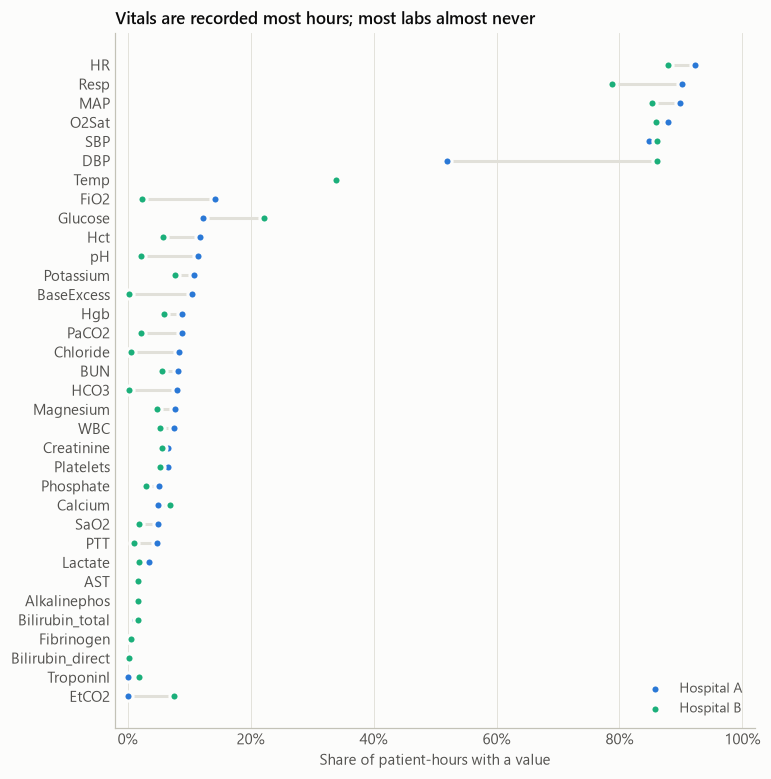

In [7]:
meas = data.MEASUREMENTS
rate = pd.DataFrame({"A": A[meas].notna().mean(), "B": B[meas].notna().mean()})
order = rate["A"].sort_values().index

fig, ax = plt.subplots(figsize=(7.5, 8.2))
y = np.arange(len(order))
for i, v in enumerate(order):
    ax.plot([rate.loc[v, "A"], rate.loc[v, "B"]], [i, i], color=viz.GRID, lw=2, zorder=1)
ax.scatter(rate.loc[order, "A"], y, s=36, color=viz.COLORS["A"], zorder=3, label="Hospital A",
           edgecolor=viz.SURFACE, linewidth=2)
ax.scatter(rate.loc[order, "B"], y, s=36, color=viz.COLORS["B"], zorder=3, label="Hospital B",
           edgecolor=viz.SURFACE, linewidth=2)
ax.set_yticks(y, order); ax.set_xlim(-0.02, 1.02)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set(title="Vitals are recorded most hours; most labs almost never",
       xlabel="Share of patient-hours with a value")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
viz.save(fig, "01_missingness")

In [8]:
r = rate.assign(**{"A ÷ B": rate.A / rate.B}).sort_values("A", ascending=False)
r.style.format({"A": "{:.1%}", "B": "{:.1%}", "A ÷ B": "{:.2f}"})

,A,B,A ÷ B
HR,92.3%,87.9%,1.05
Resp,90.2%,78.9%,1.14
MAP,89.8%,85.2%,1.05
O2Sat,88.0%,85.9%,1.02
SBP,84.8%,86.1%,0.98
DBP,51.9%,86.1%,0.60
Temp,33.8%,33.9%,1.00
FiO2,14.2%,2.3%,6.28
Glucose,12.2%,22.2%,0.55
Hct,11.8%,5.8%,2.02


**Most lab values are missing 85–99% of the time.** That is not a data-quality failure —
nobody draws a lactate every hour. Missingness here means "not measured this hour", and
the modelling steps must handle it deliberately (carry the last value forward, record how
long ago it was measured) rather than filling it with an average.

**The hospitals measure different things.** Hospital A *never* records EtCO2; hospital B
almost never records BaseExcess, HCO3, chloride or pH. A model that learns to lean on a
variable hospital B doesn't measure will lose that input at test time. This is the first
concrete reason to expect performance to drop at hospital B.

### Is *being measured* itself a warning sign?
Clinicians order tests when they are worried. Compare how often each value is recorded in
patients who are heading toward sepsis (hours *before* their label switches on) against
patients who never develop it. Hospital A only.

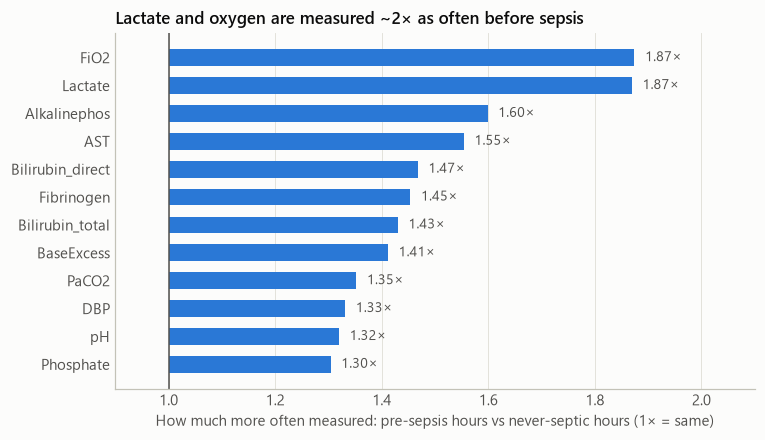

In [9]:
septic_pt = A.groupby("patient_id").SepsisLabel.transform("max") == 1
before = A[septic_pt & (A.SepsisLabel == 0)]
never = A[~septic_pt]
ratio = (before[meas].notna().mean() / never[meas].notna().mean()).dropna().sort_values()
top = ratio.tail(12)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(top.index, top.values - 1, left=1, color=viz.COLORS["series"], height=0.6)
ax.axvline(1, color=viz.INK_2, lw=1)
for i, v in enumerate(top.values):
    ax.text(v + 0.02, i, f"{v:.2f}×", va="center", color=viz.INK_2, fontsize=9)
ax.set(title="Lactate and oxygen are measured ~2× as often before sepsis",
       xlabel="How much more often measured: pre-sepsis hours vs never-septic hours (1× = same)")
ax.set_xlim(0.9, 2.1); ax.grid(axis="y", visible=False)
viz.save(fig, "01_informative_missingness")

Lactate is the lab doctors reach for when they suspect sepsis, and FiO2 is recorded when a
patient needs extra oxygen. Both are measured about **twice as often** in the hours before
sepsis. So the *pattern of measurement* carries signal on its own, and "was this measured,
and how recently" should be a feature — not something imputation erases.

One caution: this could partly be "sicker patients get more tests" rather than sepsis
specifically. It is still usable signal, but it is a reflection of **clinician behaviour**,
which can differ between hospitals — another transfer risk.

## 4 · Impossible and suspicious values

Generous plausibility limits (anything outside is physiologically impossible or a unit
error), plus consistency checks between related vitals.

In [10]:
rules = {
    "Temp < 25 °C or > 45 °C":          (A.Temp < 25) | (A.Temp > 45),
    "FiO2 > 1 (it is a fraction)":      A.FiO2 > 1,
    "BaseExcess outside ±40":           A.BaseExcess.abs() > 40,
    "HCO3 = 0":                         A.HCO3 == 0,
    "Potassium > 12":                   A.Potassium > 12,
    "MAP > 250":                        A.MAP > 250,
    "DBP ≥ SBP (diastolic above systolic)": A.DBP >= A.SBP,
    "MAP outside [DBP, SBP]":           (A.MAP < A.DBP) | (A.MAP > A.SBP),
}
checked = {"Temp < 25 °C or > 45 °C": "Temp", "FiO2 > 1 (it is a fraction)": "FiO2",
           "BaseExcess outside ±40": "BaseExcess", "HCO3 = 0": "HCO3", "Potassium > 12": "Potassium",
           "MAP > 250": "MAP", "DBP ≥ SBP (diastolic above systolic)": "DBP", "MAP outside [DBP, SBP]": "MAP"}
tab = pd.DataFrame({"hours flagged": {k: int(v.sum()) for k, v in rules.items()},
                    "patients": {k: A.loc[v, "patient_id"].nunique() for k, v in rules.items()},
                    "of recorded values": {k: v.sum() / A[checked[k]].notna().sum() for k, v in rules.items()}})
tab.style.format({"hours flagged": "{:,}", "patients": "{:,}", "of recorded values": "{:.3%}"})

,hours flagged,patients,of recorded values
Temp < 25 °C or > 45 °C,4,4,0.001%
FiO2 > 1 (it is a fraction),2,2,0.002%
BaseExcess outside ±40,3,3,0.004%
HCO3 = 0,2,2,0.003%
Potassium > 12,2,2,0.002%
MAP > 250,94,80,0.013%
DBP ≥ SBP (diastolic above systolic),92,82,0.022%
"MAP outside [DBP, SBP]","6,724","3,053",0.948%


In [11]:
floor = {v: float((A[v] == 20).mean() / A[v].notna().mean()) for v in ["HR", "O2Sat", "MAP", "DBP", "SBP"]}
print("Minimum observed value is exactly 20 for:", [v for v in floor if A[v].min() == 20])
print("Share of recorded values sitting exactly at 20:", {k: f"{v:.3%}" for k, v in floor.items()})
print(f"Age: {A.Age.min():.1f}–{A.Age.max():.0f}  (share at exactly 89: {(A.groupby('patient_id').Age.first() >= 89).mean():.1%})")

Minimum observed value is exactly 20 for: ['HR', 'O2Sat', 'MAP', 'DBP']
Share of recorded values sitting exactly at 20: {'HR': '0.002%', 'O2Sat': '0.000%', 'MAP': '0.003%', 'DBP': '0.004%', 'SBP': '0.000%'}
Age: 18.1–89  (share at exactly 89: 0.0%)


The bad values are **rare** — a fraction of a percent of recorded values — but real:
temperatures of 21 °C, FiO2 of 10 (almost certainly percent typed into a fraction field),
diastolic pressure above systolic. Heart rate, O2Sat, MAP and DBP all have a minimum of
exactly 20, which suggests a lower bound was applied when the data was prepared — but so few
values sit at 20 that it changes nothing. Ages run from 18 to 89.

One check is different: **MAP outside the [DBP, SBP] range happens in ~1% of hours**. That is
probably not bad data. Each row is an *hourly* summary, and MAP often comes from an arterial
line while SBP/DBP come from a cuff reading at another moment in the hour, so the three need
not agree. It is a limit of hourly data, not an error to fix.

The truly impossible values are rare, so the fix is simple and does not need to be clever:
set them to missing (the model then treats them as "not measured") and document the rule.

## 5 · What a patient looks like

One septic patient from hospital A, chosen by rule rather than by eye (the first patient,
in ID order, whose label switches on between ICU hours 30 and 50 and who has near-complete
vitals), so the example isn't cherry-picked for drama.

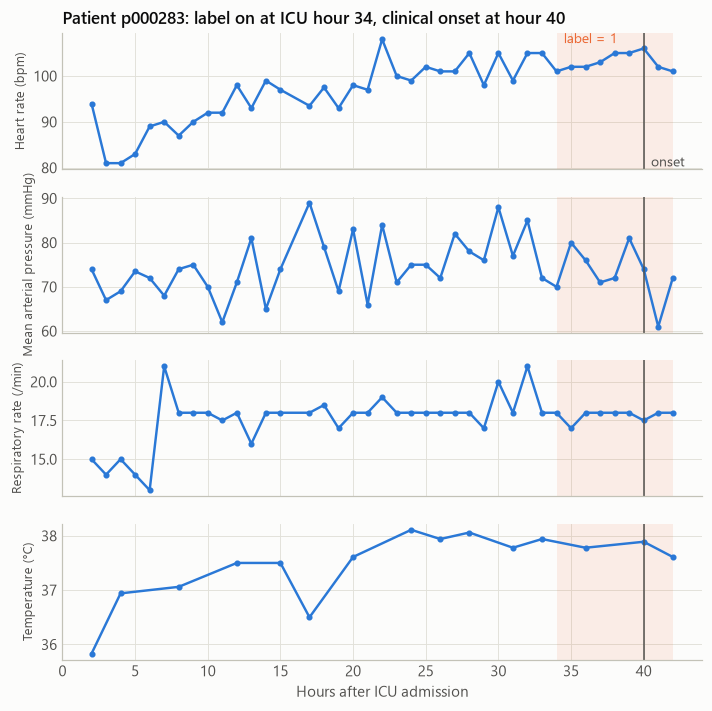

In [12]:
cand = first[(first.first_iculos >= 30) & (first.first_iculos <= 50)].index
vit_cov = A[A.patient_id.isin(cand)].groupby("patient_id")[["HR", "MAP", "Resp", "Temp"]].apply(lambda d: d.notna().mean().min())
pid = vit_cov[vit_cov >= 0.3].index.sort_values()[0]
p = A[A.patient_id == pid]
lab_on = int(first.loc[pid, "first_iculos"])

panels = [("HR", "Heart rate (bpm)"), ("MAP", "Mean arterial pressure (mmHg)"),
          ("Resp", "Respiratory rate (/min)"), ("Temp", "Temperature (°C)")]
fig, axes = plt.subplots(4, 1, figsize=(7.5, 7.4), sharex=True)
for ax, (v, lab) in zip(axes, panels):
    s = p[["ICULOS", v]].dropna()
    ax.plot(s.ICULOS, s[v], color=viz.COLORS["series"], lw=1.6, marker="o", ms=3)
    ax.axvspan(lab_on, p.ICULOS.max(), color=viz.COLORS["sepsis"], alpha=0.10, lw=0)
    ax.axvline(lab_on + 6, color=viz.INK_2, lw=1)
    ax.set_ylabel(lab, fontsize=8.5)
axes[0].set_title(f"Patient {pid}: label on at ICU hour {lab_on}, clinical onset at hour {lab_on + 6}")
axes[0].text(lab_on + 0.5, axes[0].get_ylim()[1], "label = 1", color=viz.COLORS["sepsis"], va="top", fontsize=9)
axes[0].text(lab_on + 6.5, axes[0].get_ylim()[0], "onset", color=viz.INK_2, va="bottom", fontsize=9)
axes[-1].set_xlabel("Hours after ICU admission")
viz.save(fig, "01_patient_timeline")

This patient's heart rate climbs steadily, from about 81 to 105 bpm, over the day and a
half before onset, while no single hour looks alarming on its own. Respiratory rate stays
flat; temperature rises early and plateaus. That is the case for a sequence model: some of
the signal is in **how values move over hours**, not in any one row. Notice also the gaps
(temperature is recorded every few hours) and how the record simply **ends** two hours after
onset — exactly the leakage trap described in §2.

## 6 · Summary — decisions for Step 2

| # | Finding | Decision proposed for Step 2 |
|---|---|---|
| 1 | Some patients' label is on from their first row (§2) | Decide whether to exclude them, or only start scoring after a minimum observation window |
| 2 | Septic records end ~9 h after the label switches on; record length reveals the outcome (§2) | Features may use only data up to the current hour; never whole-stay summaries |
| 3 | Row number ≠ ICU time for ~1/3 of patients (§1) | Use `ICULOS` for any time-in-ICU feature |
| 4 | Labs 85–99% missing, and *being measured* is predictive (§3) | Forward-fill last value + "hours since last measured" + a measured-yet flag; no mean imputation |
| 5 | The hospitals measure different variables (EtCO2 never at A; BaseExcess/HCO3/Cl/pH ≈ never at B) (§3) | Decide whether to drop variables the test hospital barely records, before any model sees them |
| 6 | Rare impossible values and unit errors (§4); MAP/SBP/DBP disagreement is an hourly-summary effect, not an error | Set values outside documented plausibility limits to missing; leave MAP/SBP/DBP as recorded |
| 7 | ~2% of patient-hours positive (§2) | Pick an hourly metric that handles imbalance (PR-AUC) plus the challenge's utility score |

None of these are made here. Each is put to a decision at the start of Step 2.